In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1.0, fmin=0.1, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 4, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-0.188 – 0.969 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


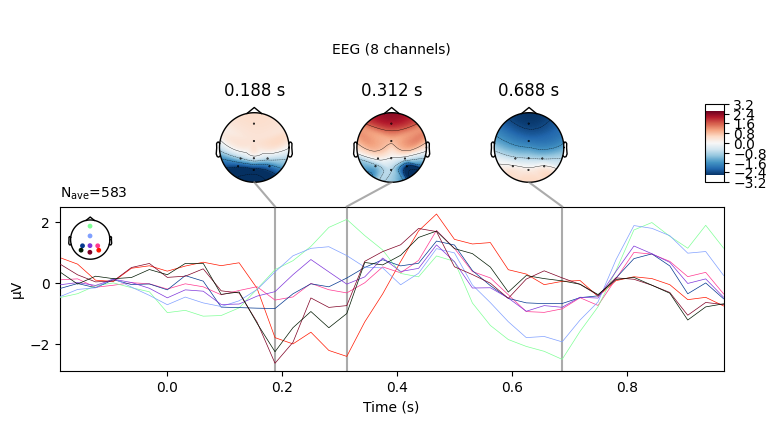

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [32]:
from hoda.hoda import BTTDA

block_rank=8
hoda = BTTDA(
    block_rank=block_rank,
    hoda_params=dict(
        max_iter=128,
        rank=(1,1),
        tol=1e-6,
        init ='mlsvd',
        verbose=True,
        shrinkage=('oas', 'oas'),
        toeplitz=(1,),
        solver='ratio_svd'
    )
)

hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0015  shrinkage=0.0260  step=1.4413e+00
[1/128]  shrinkage=0.0017  shrinkage=0.1081  step=1.5332e+00
[2/128]  shrinkage=0.0016  shrinkage=0.0241  step=1.1455e+00
[3/128]  shrinkage=0.0017  shrinkage=0.1162  step=1.0377e+00
[4/128]  shrinkage=0.0016  shrinkage=0.0329  step=9.0897e-01
[5/128]  shrinkage=0.0016  shrinkage=0.1195  step=7.4570e-01
[6/128]  shrinkage=0.0016  shrinkage=0.0768  step=4.5972e-01
[7/128]  shrinkage=0.0016  shrinkage=0.1208  step=3.2188e-01
[8/128]  shrinkage=0.0016  shrinkage=0.1178  step=1.5707e-01
[9/128]  shrinkage=0.0016  shrinkage=0.1213  step=9.1107e-02
[10/128]  shrinkage=0.0016  shrinkage=0.1217  step=5.1387e-02
[11/128]  shrinkage=0.0016  shrinkage=0.1215  step=2.8150e-02
[12/128]  shrinkage=0.0016  shrinkage=0.1217  step=1.6547e-02
[13/128]  shrinkage=0.0016  shrinkage=0.1216  step=8.8218e-03
[14/128]  shrinkage=0.0016  shrinkage=0.1217  step=5.3377e-03
[15/128]  shrinkage=0.0016  shrinkage=0.1216  step=2.7659e-03
[16/128]  shrinkag

[71/128]  shrinkage=0.0017  shrinkage=0.0573  step=1.5344e-03
[72/128]  shrinkage=0.0017  shrinkage=0.0573  step=1.4088e-03
[73/128]  shrinkage=0.0017  shrinkage=0.0573  step=1.2534e-03
[74/128]  shrinkage=0.0017  shrinkage=0.0573  step=1.1508e-03
[75/128]  shrinkage=0.0017  shrinkage=0.0573  step=1.0239e-03
[76/128]  shrinkage=0.0017  shrinkage=0.0573  step=9.3999e-04
[77/128]  shrinkage=0.0017  shrinkage=0.0573  step=8.3628e-04
[78/128]  shrinkage=0.0017  shrinkage=0.0573  step=7.6777e-04
[79/128]  shrinkage=0.0017  shrinkage=0.0573  step=6.8305e-04
[80/128]  shrinkage=0.0017  shrinkage=0.0573  step=6.2708e-04
[81/128]  shrinkage=0.0017  shrinkage=0.0573  step=5.5787e-04
[82/128]  shrinkage=0.0017  shrinkage=0.0573  step=5.1216e-04
[83/128]  shrinkage=0.0017  shrinkage=0.0573  step=4.5563e-04
[84/128]  shrinkage=0.0017  shrinkage=0.0573  step=4.1829e-04
[85/128]  shrinkage=0.0017  shrinkage=0.0573  step=3.7211e-04
[86/128]  shrinkage=0.0017  shrinkage=0.0573  step=3.4161e-04
[87/128]

[86/128]  shrinkage=0.0019  shrinkage=0.0287  step=4.3598e-03
[87/128]  shrinkage=0.0019  shrinkage=0.0284  step=4.0151e-03
[88/128]  shrinkage=0.0019  shrinkage=0.0287  step=3.7105e-03
[89/128]  shrinkage=0.0019  shrinkage=0.0284  step=3.4174e-03
[90/128]  shrinkage=0.0019  shrinkage=0.0287  step=3.1584e-03
[91/128]  shrinkage=0.0019  shrinkage=0.0284  step=2.9090e-03
[92/128]  shrinkage=0.0019  shrinkage=0.0287  step=2.6887e-03
[93/128]  shrinkage=0.0019  shrinkage=0.0285  step=2.4765e-03
[94/128]  shrinkage=0.0019  shrinkage=0.0287  step=2.2891e-03
[95/128]  shrinkage=0.0019  shrinkage=0.0285  step=2.1085e-03
[96/128]  shrinkage=0.0019  shrinkage=0.0287  step=1.9490e-03
[97/128]  shrinkage=0.0019  shrinkage=0.0285  step=1.7953e-03
[98/128]  shrinkage=0.0019  shrinkage=0.0286  step=1.6596e-03
[99/128]  shrinkage=0.0019  shrinkage=0.0285  step=1.5287e-03
[100/128]  shrinkage=0.0019  shrinkage=0.0286  step=1.4132e-03
[101/128]  shrinkage=0.0019  shrinkage=0.0285  step=1.3018e-03
[102/1

[36/128]  shrinkage=0.0017  shrinkage=0.0563  step=1.4411e-03
[37/128]  shrinkage=0.0017  shrinkage=0.0564  step=1.1129e-03
[38/128]  shrinkage=0.0017  shrinkage=0.0563  step=8.2108e-04
[39/128]  shrinkage=0.0017  shrinkage=0.0564  step=6.3412e-04
[40/128]  shrinkage=0.0017  shrinkage=0.0563  step=4.6768e-04
[41/128]  shrinkage=0.0017  shrinkage=0.0564  step=3.6116e-04
[42/128]  shrinkage=0.0017  shrinkage=0.0564  step=2.6633e-04
[43/128]  shrinkage=0.0017  shrinkage=0.0564  step=2.0568e-04
[44/128]  shrinkage=0.0017  shrinkage=0.0564  step=1.5165e-04
[45/128]  shrinkage=0.0017  shrinkage=0.0564  step=1.1712e-04
[46/128]  shrinkage=0.0017  shrinkage=0.0564  step=8.6355e-05
[47/128]  shrinkage=0.0017  shrinkage=0.0564  step=6.6691e-05
[48/128]  shrinkage=0.0017  shrinkage=0.0564  step=4.9146e-05
[49/128]  shrinkage=0.0017  shrinkage=0.0564  step=3.7942e-05
[50/128]  shrinkage=0.0017  shrinkage=0.0564  step=2.7971e-05
[51/128]  shrinkage=0.0017  shrinkage=0.0564  step=2.1608e-05
[52/128]

[115/128]  shrinkage=0.0020  shrinkage=0.0882  step=1.3751e+00
[116/128]  shrinkage=0.0016  shrinkage=0.0261  step=1.3751e+00
[117/128]  shrinkage=0.0020  shrinkage=0.0882  step=1.3751e+00
[118/128]  shrinkage=0.0016  shrinkage=0.0261  step=1.3751e+00
[119/128]  shrinkage=0.0020  shrinkage=0.0882  step=1.3751e+00
[120/128]  shrinkage=0.0016  shrinkage=0.0261  step=1.3751e+00
[121/128]  shrinkage=0.0020  shrinkage=0.0882  step=1.3751e+00
[122/128]  shrinkage=0.0016  shrinkage=0.0261  step=1.3751e+00
[123/128]  shrinkage=0.0020  shrinkage=0.0882  step=1.3751e+00
[124/128]  shrinkage=0.0016  shrinkage=0.0261  step=1.3751e+00
[125/128]  shrinkage=0.0020  shrinkage=0.0882  step=1.3751e+00
[126/128]  shrinkage=0.0016  shrinkage=0.0261  step=1.3751e+00
[127/128]  shrinkage=0.0020  shrinkage=0.0882  step=1.3751e+00
[0/128]  shrinkage=0.0015  shrinkage=0.0262  step=1.4424e+00
[1/128]  shrinkage=0.0017  shrinkage=0.0765  step=1.2610e+00
[2/128]  shrinkage=0.0016  shrinkage=0.0198  step=1.0688e+0

[122/128]  shrinkage=0.0017  shrinkage=0.0571  step=2.2360e-02
[123/128]  shrinkage=0.0017  shrinkage=0.0574  step=1.6199e-02
[124/128]  shrinkage=0.0017  shrinkage=0.0571  step=1.2397e-02
[125/128]  shrinkage=0.0017  shrinkage=0.0573  step=9.0054e-03
[126/128]  shrinkage=0.0017  shrinkage=0.0571  step=6.8390e-03
[127/128]  shrinkage=0.0017  shrinkage=0.0573  step=4.9243e-03


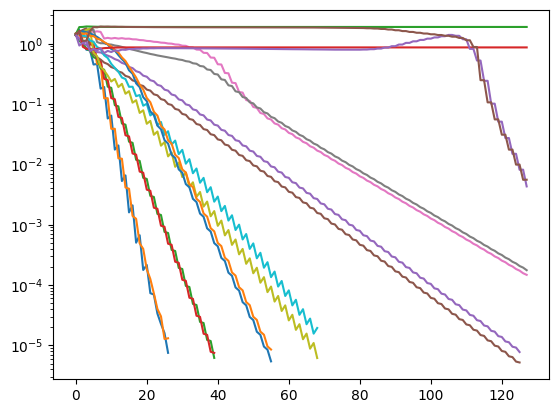

In [33]:
import cupy

for b in range(block_rank):
    plt.semilogy(cupy.asnumpy(hoda.blocks_[b].updates_))
plt.show()

No projector specified for this dataset. Please consider the method self.add_proj.


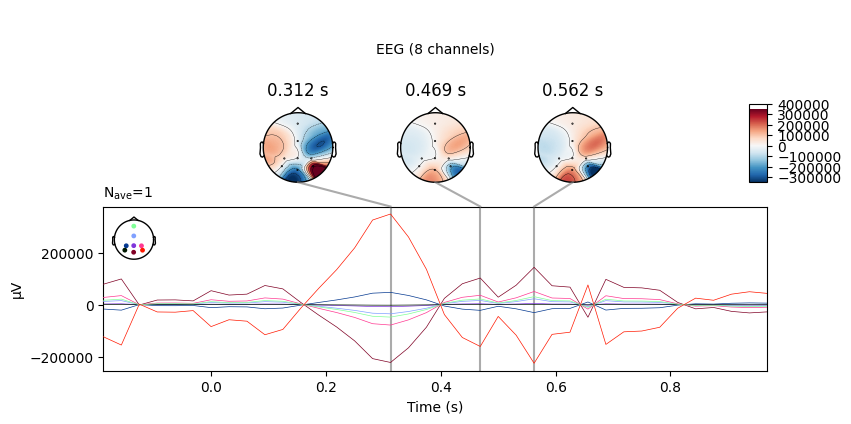

No projector specified for this dataset. Please consider the method self.add_proj.


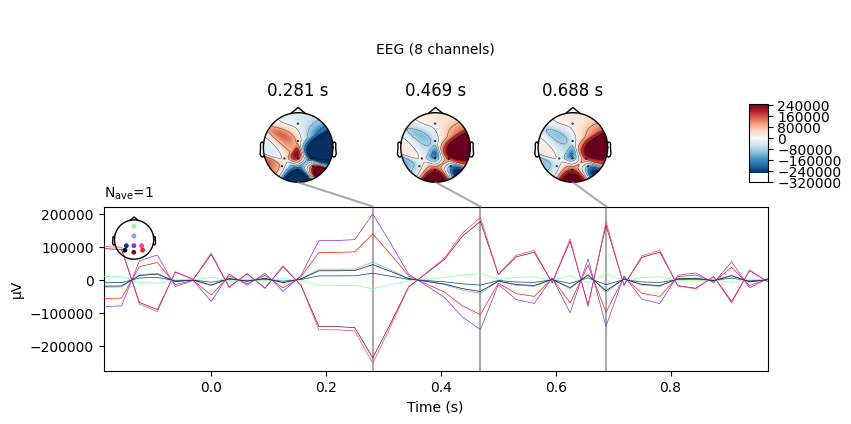

No projector specified for this dataset. Please consider the method self.add_proj.


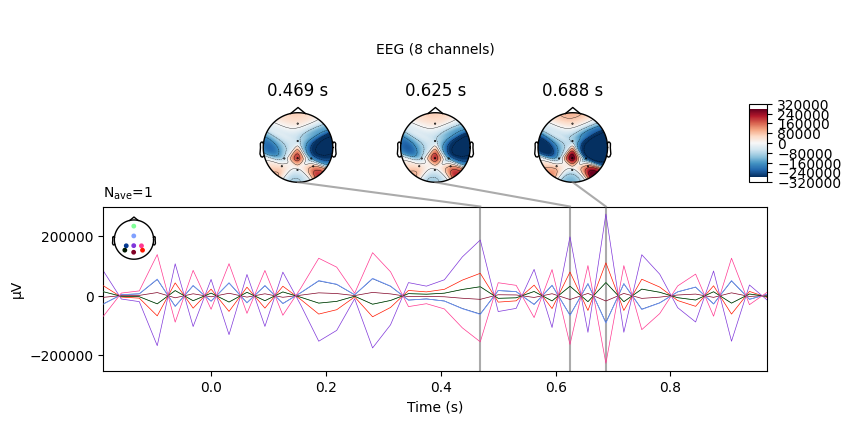

No projector specified for this dataset. Please consider the method self.add_proj.


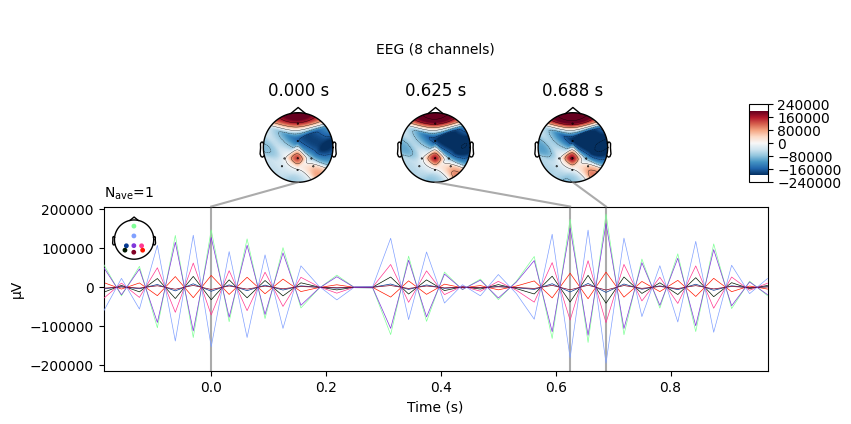

No projector specified for this dataset. Please consider the method self.add_proj.


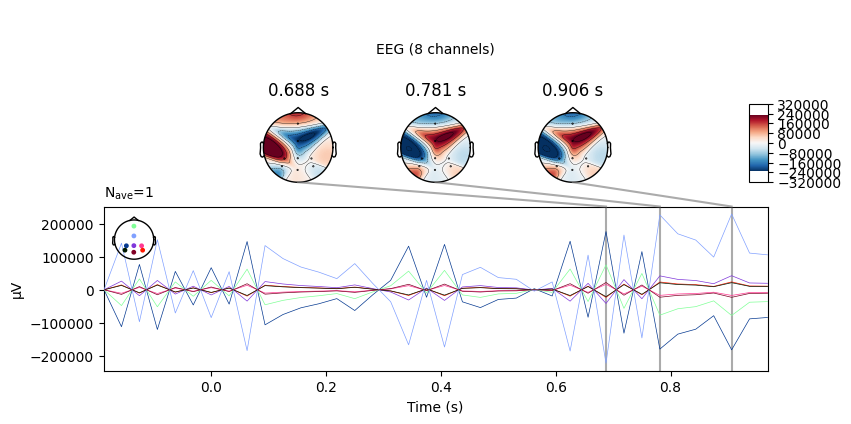

No projector specified for this dataset. Please consider the method self.add_proj.


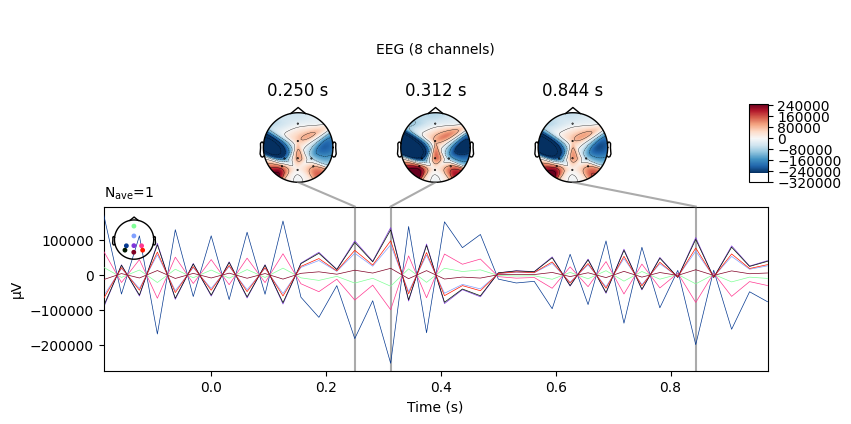

No projector specified for this dataset. Please consider the method self.add_proj.


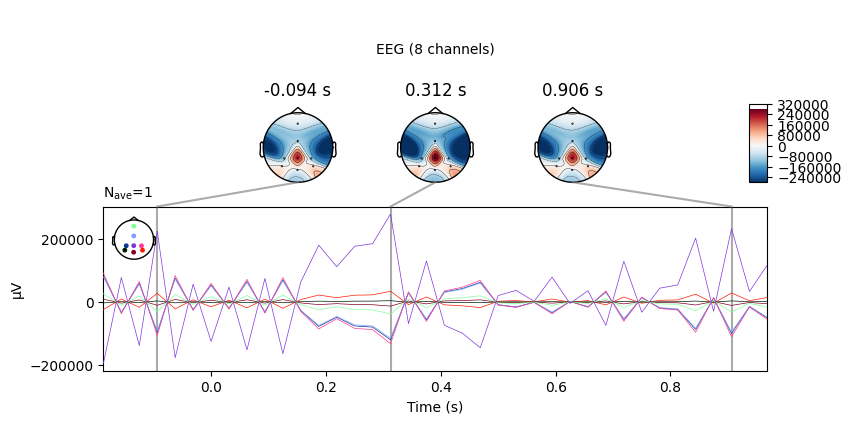

No projector specified for this dataset. Please consider the method self.add_proj.


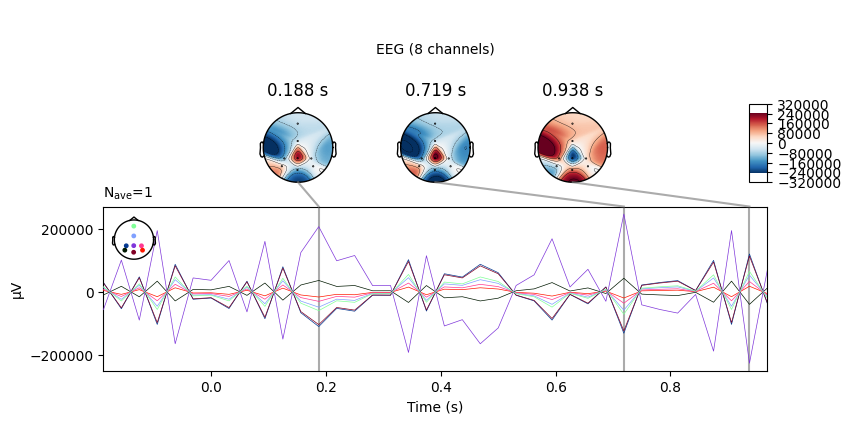

In [34]:
from mne import EvokedArray

for i in range(block_rank):
    w_sp = cupy.asnumpy(hoda.blocks_[i].projs_[0].squeeze())
    w_tmp = cupy.asnumpy(hoda.blocks_[i].projs_[1].squeeze())
    w = np.outer(w_sp, w_tmp)
    w = EvokedArray(w, epochs.info, epochs.tmin)
    w.plot_joint()

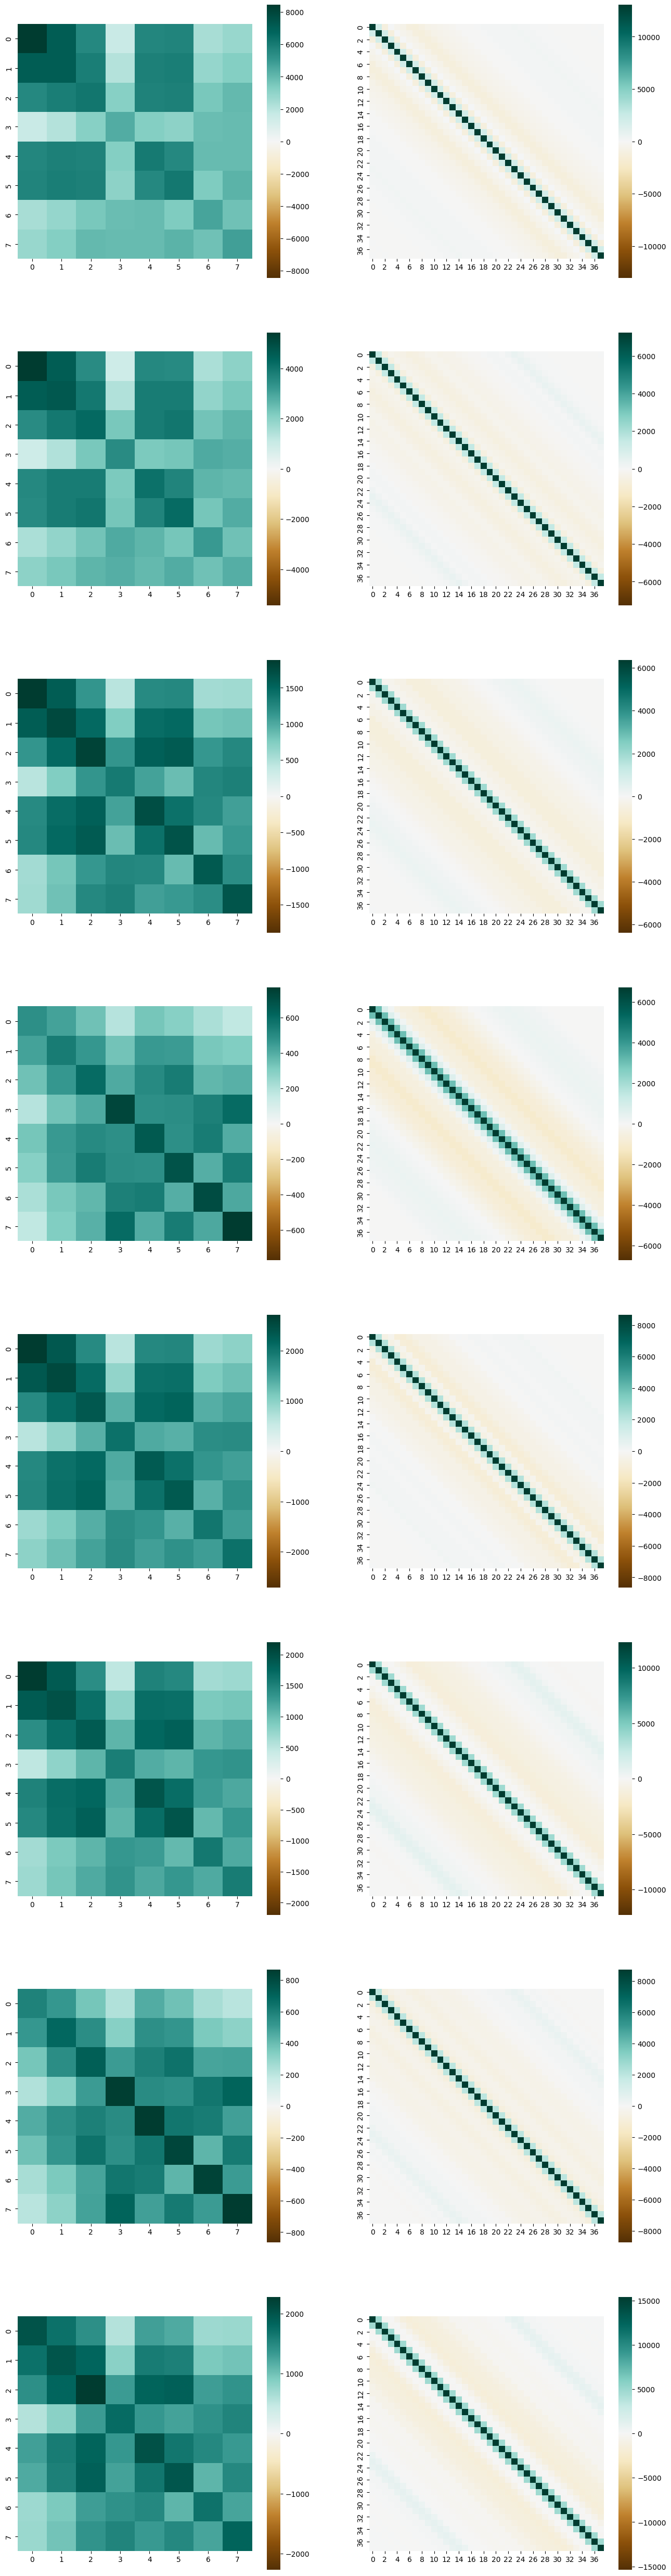

In [35]:
fig, axs = plt.subplots(block_rank,2, figsize=(16,8*block_rank))
for b in range(block_rank):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])
        axs[b,k].set_aspect('equal')

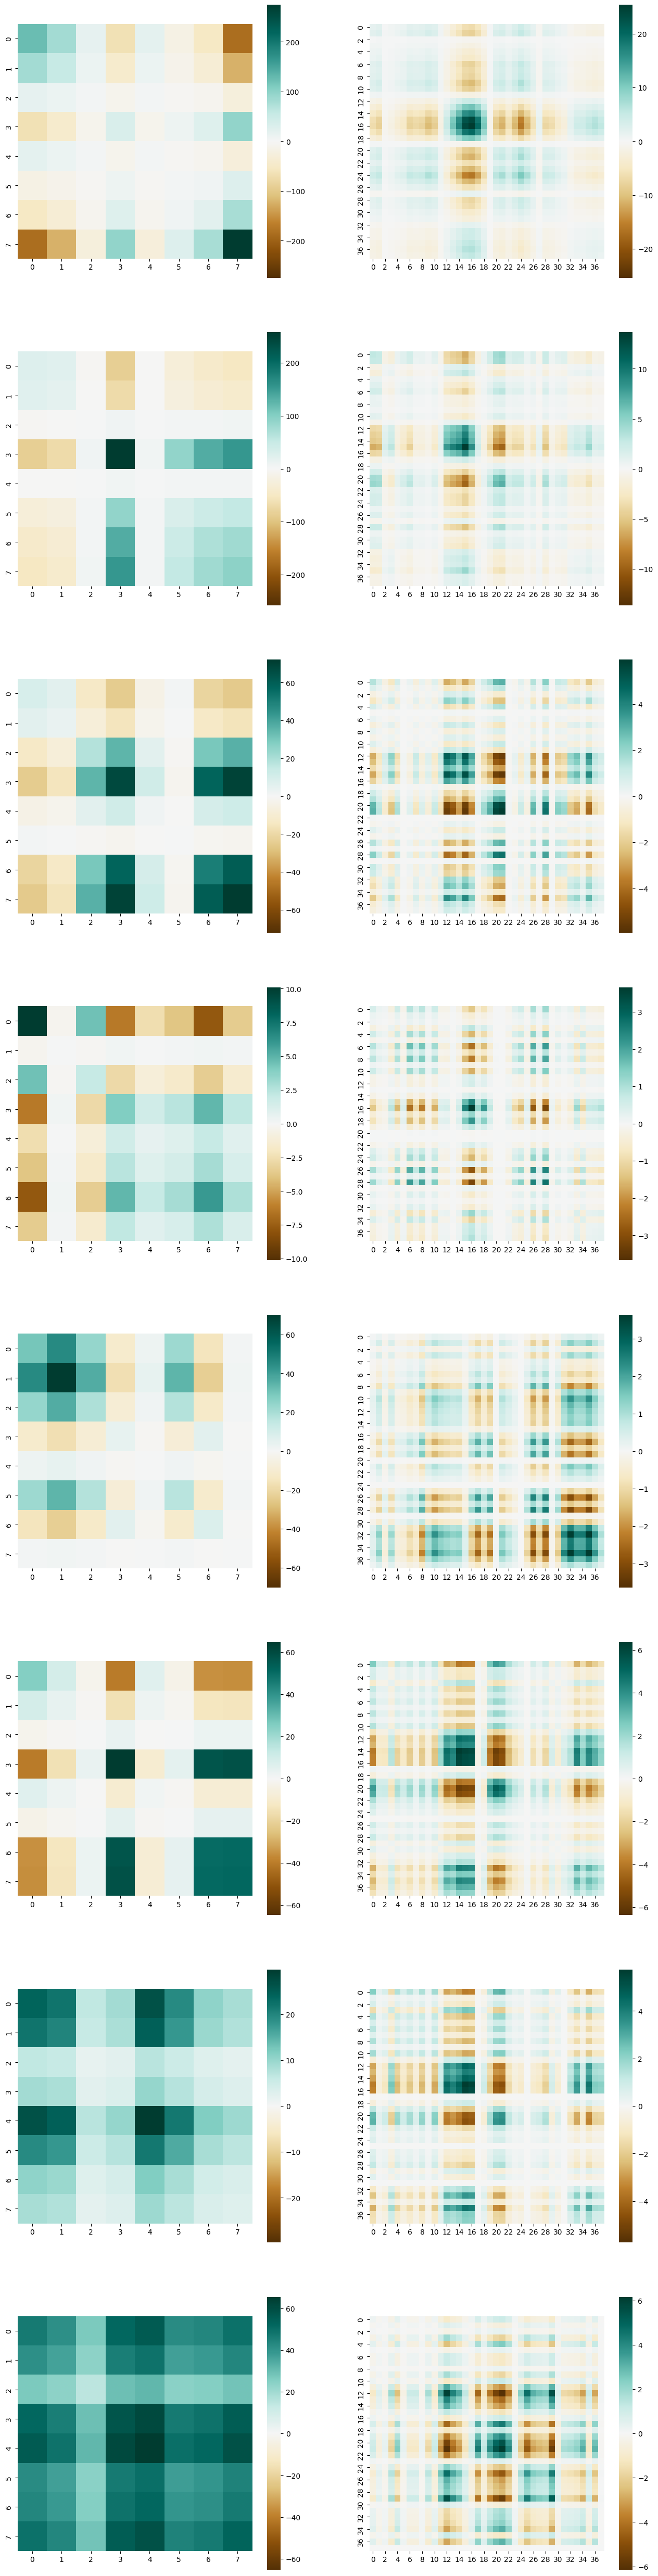

In [36]:
fig, axs = plt.subplots(block_rank,2, figsize=(16,8*block_rank))
for b in range(block_rank):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_b_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])
        axs[b,k].set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


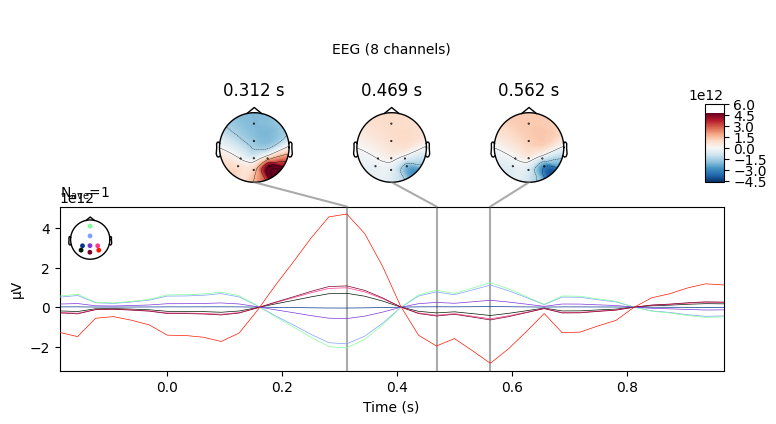

No projector specified for this dataset. Please consider the method self.add_proj.


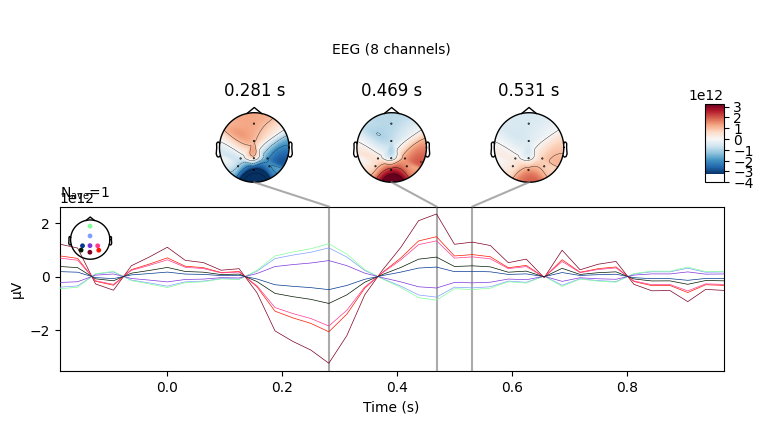

No projector specified for this dataset. Please consider the method self.add_proj.


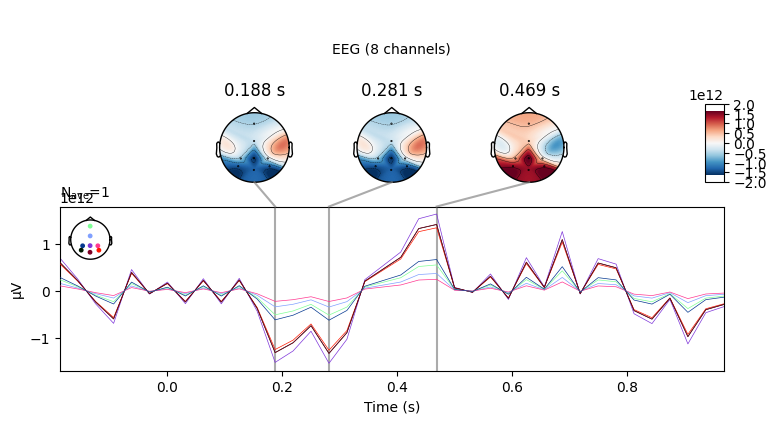

No projector specified for this dataset. Please consider the method self.add_proj.


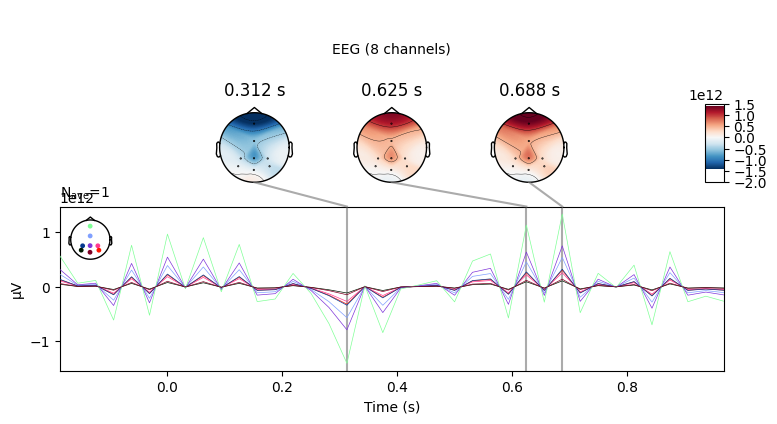

No projector specified for this dataset. Please consider the method self.add_proj.


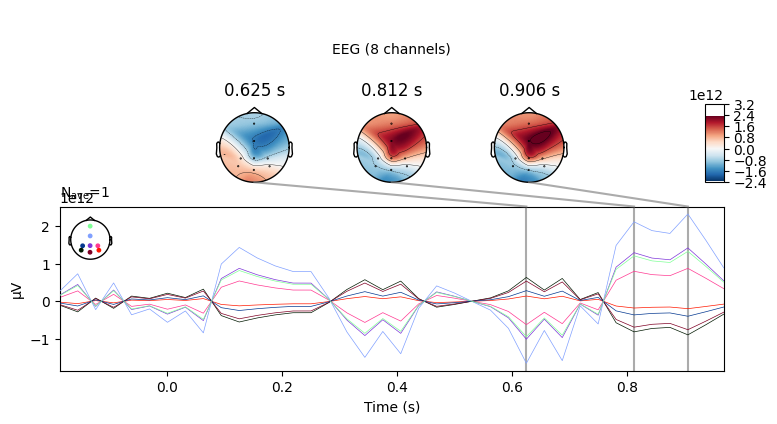

No projector specified for this dataset. Please consider the method self.add_proj.


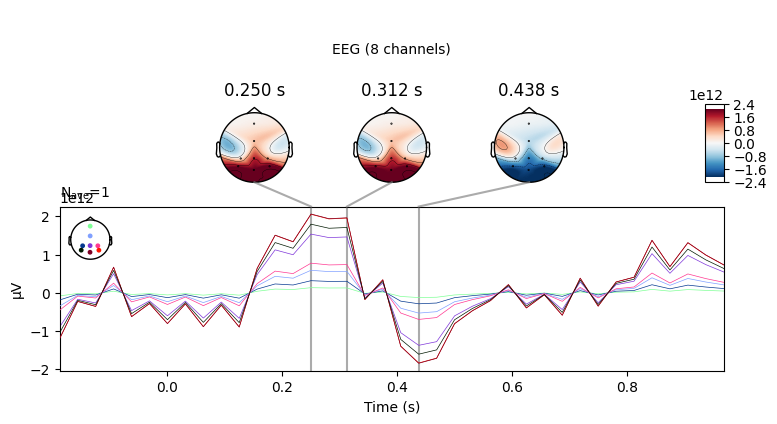

No projector specified for this dataset. Please consider the method self.add_proj.


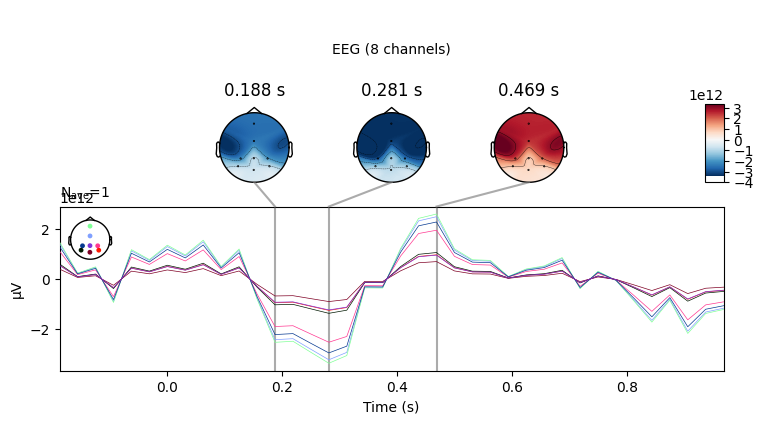

No projector specified for this dataset. Please consider the method self.add_proj.


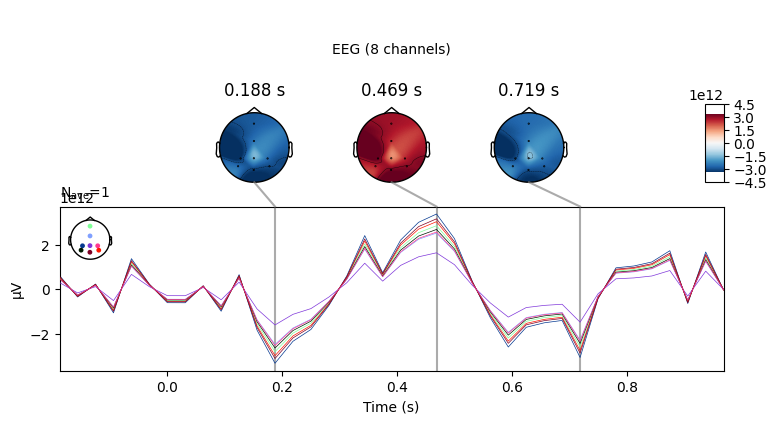

In [37]:
for i in range(block_rank):
    w_sp = hoda.blocks_[i].projs_[0].squeeze()
    w_tmp = hoda.blocks_[i].projs_[1].squeeze()
    ap_sp = cupy.asnumpy(hoda.blocks_[b].scatter_w_[0] @ w_sp)
    ap_tmp = cupy.asnumpy(hoda.blocks_[b].scatter_w_[1] @ w_tmp)
    ap = np.outer(ap_sp, ap_tmp)
    ap = EvokedArray(ap, epochs.info, epochs.tmin)
    ap.plot_joint()

In [38]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)


LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [40]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

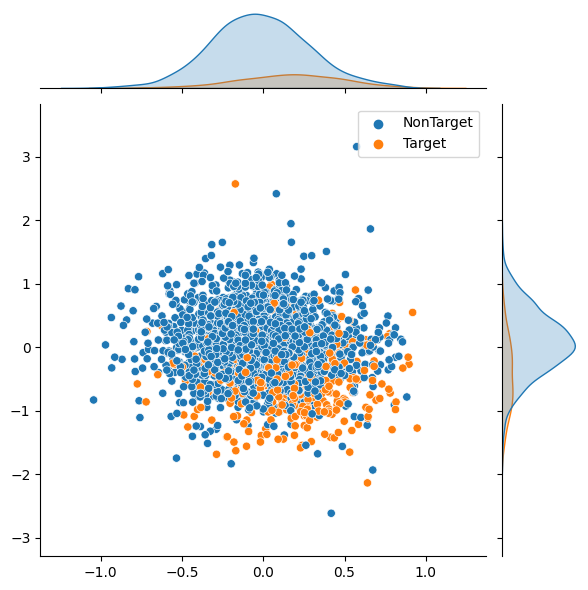

In [41]:
import seaborn as sns

g = sns.jointplot(x=Xt_train[:,f1],y=Xt_train[:,f2], hue=y_train)

In [42]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.8015706122448978

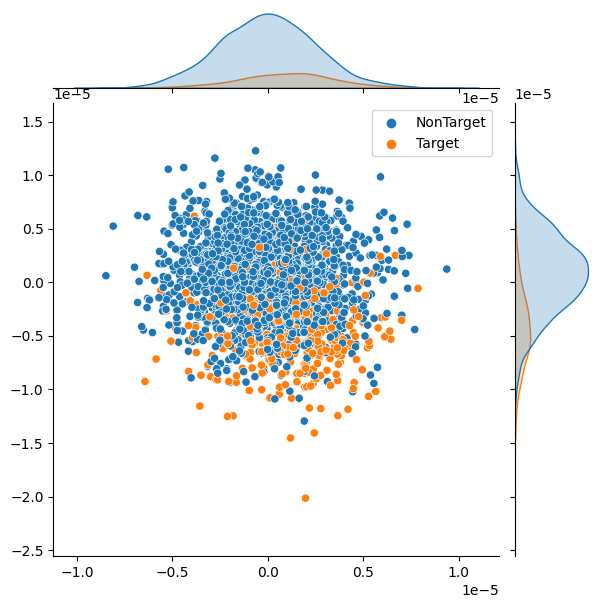

In [43]:
g = sns.jointplot(x=Xt_test[:,f1],y=Xt_test[:,f2], hue=y_test)

In [44]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.8199020408163266